In [1]:
from dotenv import load_dotenv
load_dotenv()

True

## Use Tavily

In [2]:
from langchain_tavily import TavilySearch

In [3]:
tavily_search_tool = TavilySearch(
    max_results=5,
    topic="general",
)

In [4]:
user_input = "What nation hosted the Euro 2024? Include only wikipedia sources."

In [5]:
# tavily_search_tool.invoke({'query': user_input})

In [6]:
from langgraph.graph import StateGraph, START, END, MessagesState

In [7]:
from planner_agent_state import PlannerAgentState

In [8]:
workflow = StateGraph(PlannerAgentState)

In [9]:
from langchain.chat_models import init_chat_model

In [10]:
llm = init_chat_model('gpt-4o-mini', model_provider='openai')

In [11]:
# llm.invoke('What is capital of China?')

In [12]:
from destination_prompt import prompt as find_destination_prompt
from summary_prompt import summary_prompt

In [13]:
from user_destination import destination_parser, format_destination_info

## Create nodes for the workflow

In [14]:
from query_generator import build_query

In [15]:
## Extract location Node
def extract_location(state: PlannerAgentState) -> PlannerAgentState:
    messages = state.get('messages', [])
    user_query = ''
    if (len(messages) > 0):
        user_query = messages[0]

    if (user_query):
        chain = find_destination_prompt | llm | destination_parser
        response = chain.invoke({'user_input': user_query})
        return {'destination_info': response}
    return state

In [16]:
## Attractions Node
def attractions(state: PlannerAgentState) -> PlannerAgentState:
    destination_info = state.get('destination_info', {})
    query = build_query(base_text="Top tourist attractions", destination_info=destination_info)
    tavily_response = tavily_search_tool.invoke({'query': query})
    tavily_response_results = tavily_response.get('results', [])
    accumulated_content = '\n'.join([result.get('content', '') for result in tavily_response_results])
    return {'messages': [accumulated_content]}

In [17]:
## Restaurants Node
def restaurants(state: PlannerAgentState) -> PlannerAgentState:
    destination_info = state.get('destination_info', {})
    query = build_query(base_text="Best local restaurants and popular cuisine", destination_info=destination_info)
    tavily_response = tavily_search_tool.invoke({'query': query})
    tavily_response_results = tavily_response.get('results', [])
    accumulated_content = '\n'.join([result.get('content', '') for result in tavily_response_results])
    return {'messages': [accumulated_content]}

In [18]:
## Transportation Node
def transportation(state: PlannerAgentState) -> PlannerAgentState:
    destination_info = state.get('destination_info', {})
    query = build_query(base_text="Public transportation options and how to get around", destination_info=destination_info)
    tavily_response = tavily_search_tool.invoke({'query': query})
    tavily_response_results = tavily_response.get('results', [])
    accumulated_content = '\n'.join([result.get('content', '') for result in tavily_response_results])
    return {'messages': [accumulated_content]}

In [19]:
## current_weather Node
def current_weather(state: PlannerAgentState) -> PlannerAgentState:
    destination_info = state.get('destination_info', {})
    query = build_query(base_text="Current weather conditions", destination_info=destination_info)
    tavily_response = tavily_search_tool.invoke({'query': query})
    tavily_response_results = tavily_response.get('results', [])
    accumulated_content = '\n'.join([result.get('content', '') for result in tavily_response_results])
    return {'messages': [accumulated_content]}

In [20]:
## Weather Forecast Node
def weather_forecast(state: PlannerAgentState) -> PlannerAgentState:
    destination_info = state.get('destination_info', {})
    query = build_query(base_text="7-day weather forecast", destination_info=destination_info)
    tavily_response = tavily_search_tool.invoke({'query': query})
    tavily_response_results = tavily_response.get('results', [])
    accumulated_content = '\n'.join([result.get('content', '') for result in tavily_response_results])
    return {'messages': [accumulated_content]}

In [21]:
## Hotel Search Node
def hotel_search(state: PlannerAgentState) -> PlannerAgentState:
    destination_info = state.get('destination_info', {})
    query = build_query(base_text="Best hotels to stay", destination_info=destination_info)
    tavily_response = tavily_search_tool.invoke({'query': query})
    tavily_response_results = tavily_response.get('results', [])
    accumulated_content = '\n'.join([result.get('content', '') for result in tavily_response_results])
    return {'messages': [accumulated_content]}

In [22]:
## Summarizer node
def summarizer(state: PlannerAgentState) -> PlannerAgentState:
    messages = state.get('messages', [])
    destination_info = state.get('destination_info', {})

    user_query = messages[0]
    search_results = messages[1:]

    search_results_content = list(map(lambda search_result: search_result.content, search_results))

    accumulated_search_results = '\n\n'.join([result for result in search_results_content])

    chain = summary_prompt | llm

    response = chain.invoke({'user_query': user_query, 'destination_info': format_destination_info(destination_info), 'search_results': accumulated_search_results})

    return {'messages': [response.content]}

### Add nodes to the workflow

In [23]:
workflow.add_node('extract_location', extract_location)
workflow.add_node('attractions', attractions)
workflow.add_node('restaurants', restaurants)
workflow.add_node('transportation', transportation)
workflow.add_node('current_weather', current_weather)
workflow.add_node('weather_forecast', weather_forecast)
workflow.add_node('hotel_search', hotel_search)
workflow.add_node('summarizer', summarizer)

### Create edges

In [24]:
workflow.add_edge(START, 'extract_location')

workflow.add_edge('extract_location', 'attractions')
workflow.add_edge('extract_location', 'restaurants')
workflow.add_edge('extract_location', 'transportation')
workflow.add_edge('extract_location', 'current_weather')
workflow.add_edge('extract_location', 'weather_forecast')
workflow.add_edge('extract_location', 'hotel_search')

In [25]:
workflow.add_edge('attractions', 'summarizer')
workflow.add_edge('restaurants', 'summarizer')
workflow.add_edge('transportation', 'summarizer')
workflow.add_edge('current_weather', 'summarizer')
workflow.add_edge('weather_forecast', 'summarizer')
workflow.add_edge('hotel_search', 'summarizer')

In [26]:
workflow.add_edge('summarizer', END)

In [27]:
app = workflow.compile()

In [28]:
from IPython.display import display, Image

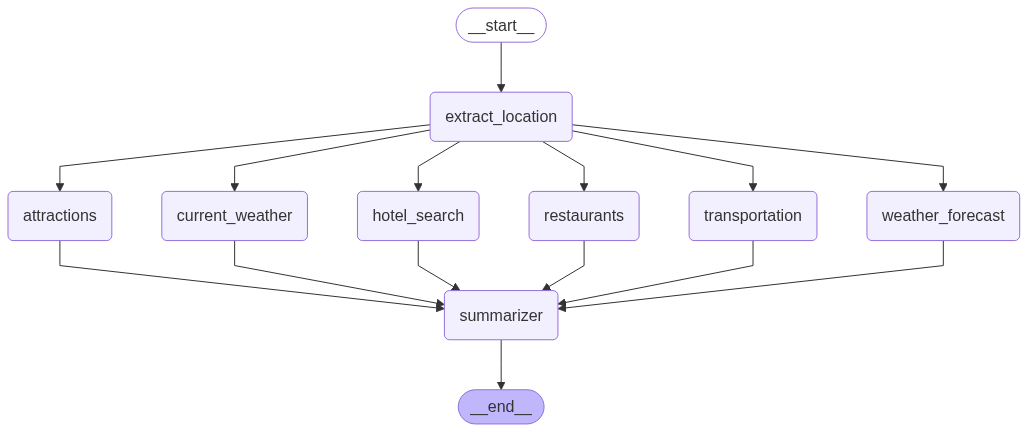

In [29]:
display(Image(app.get_graph().draw_mermaid_png()))

In [30]:
user_query = 'I want to visit Kyoto next spring. What can you tell me about getting around there?'
user_query_2 = 'Plan a cultural itinerary in Jaipur, focusing on historic landmarks.'

In [31]:
# for output in app.stream({'messages': [user_query_2]}):
#     print('##output', output)

In [32]:
response = app.invoke({'messages': [user_query_2]})

In [33]:
messages = response.get('messages', [])

In [34]:
from pprint import pprint

In [35]:
for message in messages:
    message.pretty_print()

================================ Human Message =================================

Plan a cultural itinerary in Jaipur, focusing on historic landmarks.
================================ Human Message =================================

Jaipur City Palace, Jaipur  The magnificent City Palace in Jaipur is one of the most famous tourist attractions located in the old part of the city. Probably one of the most significant temples for Krishna followers after Vrindavan, Govind Dev Temple is located within the City Palace of Jaipur. The following day tourists can visit Hawa Mahal and the Jaipur Jantar Mantar, a UNESCO world heritage site and the Sun temple. On the third and fourth days, tourists can visit the Jaipur Zoo, Albert Hall Museum, Birla Temple, Lakshmi Narayan Temple, Amber Fort and Palace, and the Nahargarh Fort. The top sightseeing places in Jaipur are Amer Fort, City Palace, Jaipur, Hawa Mahal, Jantar Mantar Jaipur, Nahargarh Fort, Pink City.
Highlights include the beautifully decor